# _Segmentaçõ, Processamento do Dataset...._

# ⬇️ | Imports

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops, label
from sklearn.model_selection import train_test_split

# ⬇️ | Dataset

In [3]:
## dataset disponivel no Kaggle
## Kaggle - https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification/data


DATASET_PATH = Path("../dataset")


TRAIN_PATH = DATASET_PATH / "train"

TEST_PATH = DATASET_PATH / "test"


print("DATASET:", DATASET_PATH)

print("TRAIN:", TRAIN_PATH)

print("TEST:", TEST_PATH)

print()

print("TRAIN EXISTE:", TRAIN_PATH.exists())

print("TEST EXISTE:", TEST_PATH.exists())

DATASET: ..\dataset
TRAIN: ..\dataset\train
TEST: ..\dataset\test

TRAIN EXISTE: True
TEST EXISTE: True


# 🥸 | Características


## 🧩 | Segmentação - HSV e Morphology


In [4]:
def segmentar_hsv(img):

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower = np.array([0, 40, 20])

    upper = np.array([179, 255, 255])

    mascara = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((5,5), np.uint8)

    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)

    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

    return mascara

## 🎲 | Features

In [5]:
def extrair_shape_features(mask):

    rotulos = label(mask)

    props = regionprops(rotulos)

    if len(props) == 0:

        return [0,0,0,0,0,0]

    obj = max(props,key=lambda x: x.area)

    area = obj.area

    perimeter = obj.perimeter

    eccentricity = obj.eccentricity

    solidity = obj.solidity

    extent = obj.extent

    circularity = (4*np.pi*area) / (perimeter**2 + 1e-8)

    return [
        area,
        perimeter,
        eccentricity,
        solidity,
        extent,
        circularity
    ]

## 😶‍🌫️ | Hu moments

In [6]:
def extrair_hu(mask):

    momentos = cv2.moments(mask)

    hu = cv2.HuMoments(momentos)

    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    return hu.flatten().tolist()

## 🎨 | Color Features

In [7]:
def extrair_cor(img, mask):
    pixels_bgr = img[mask > 0]
    if len(pixels_bgr) == 0:
        return [0,0,0, 0,0,0] 
        
    media_bgr = np.mean(pixels_bgr, axis=0)

    
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    pixels_hsv = img_hsv[mask > 0]
    media_hsv = np.mean(pixels_hsv, axis=0)

   
    return media_bgr.tolist() + media_hsv.tolist()

## 💡| Texture Features

In [8]:
def extrair_glcm(img_gray, mask):

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return [0,0,0,0]


    x1 = xs.min()
    x2 = xs.max()

    y1 = ys.min()
    y2 = ys.max()


    roi = img_gray[y1:y2, x1:x2]


    glcm = graycomatrix(
        roi,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )


    contrast = graycoprops(glcm, "contrast")[0,0]

    homogeneity = graycoprops(glcm, "homogeneity")[0,0]

    energy = graycoprops(glcm, "energy")[0,0]

    correlation = graycoprops(glcm, "correlation")[0,0]


    return [
        contrast,
        homogeneity,
        energy,
        correlation
    ]

# 🧮 | Processamento

In [9]:
from sklearn.model_selection import train_test_split


lista_train = []
labels_train = []

lista_test = []
labels_test = []


for origem, imagens_lista, labels_lista in [

    (
        TRAIN_PATH,
        lista_train,
        labels_train
    ),

    (
        TEST_PATH,
        lista_test,
        labels_test
    )

]:

    for pasta in origem.iterdir():

        if not pasta.is_dir():

            continue

        classe = pasta.name.lower()

        classe_label = (
            "Fresh"
            if "fresh" in classe
            else "Rotten"
        )

        imagens = []

        imagens.extend(list(pasta.glob("*.jpg")))
        imagens.extend(list(pasta.glob("*.jpeg")))
        imagens.extend(list(pasta.glob("*.png")))

        for img in imagens:

            imagens_lista.append(
                str(img)
            )

            labels_lista.append(
                classe_label
            )


# CRIAR VALIDAÇÃO A PARTIR DO TREINO
lista_train, lista_val, labels_train, labels_val = train_test_split(

    lista_train,

    labels_train,

    test_size=0.15,

    random_state=42,

    stratify=labels_train
)


print()

print(
    "Train:",
    len(lista_train)
)

print(
    "Val:",
    len(lista_val)
)

print(
    "Test:",
    len(lista_test)
)


Train: 9265
Val: 1636
Test: 2698


#### Features

In [10]:
def gerar_features(paths, labels):

    X = []

    for caminho in tqdm(paths):

        img = cv2.imread(caminho)

        mask = segmentar_hsv(img)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        shape = extrair_shape_features(mask)

        hu = extrair_hu(mask)

        cor = extrair_cor(img, mask)

        glcm = extrair_glcm(gray, mask)

        features = shape + hu + cor + glcm

        X.append(features)

    return pd.DataFrame(X), labels

## 📔 | DataFrame

In [11]:
colunas = [
"area",
"perimeter",
"eccentricity",
"solidity",
"extent",
"circularity",

"hu1",
"hu2",
"hu3",
"hu4",
"hu5",
"hu6",
"hu7",

"mean_b",
"mean_g",
"mean_r",

"mean_h",
"mean_s",
"mean_v",

"contrast",
"homogeneity",
"energy",
"correlation"
]


X_train_df, y_train_df = gerar_features(
    lista_train,
    labels_train
)

X_val_df, y_val_df = gerar_features(
    lista_val,
    labels_val
)

X_test_df, y_test_df = gerar_features(
    lista_test,
    labels_test
)


# COLUNAS
X_train_df.columns = colunas
X_val_df.columns = colunas
X_test_df.columns = colunas

# ANALISAR TAMANHO ANTES
print("ANTES")
print("Train:", X_train_df.shape)
print("Val:", X_val_df.shape)
print("Test:", X_test_df.shape)


# REMOVER DUPLICATAS
indices_train = X_train_df.drop_duplicates().index
indices_val = X_val_df.drop_duplicates().index
indices_test = X_test_df.drop_duplicates().index

X_train_df = X_train_df.loc[indices_train]
y_train_df = pd.Series(y_train_df).loc[indices_train]

X_val_df = X_val_df.loc[indices_val]
y_val_df = pd.Series(y_val_df).loc[indices_val]

X_test_df = X_test_df.loc[indices_test]
y_test_df = pd.Series(y_test_df).loc[indices_test]

print("DEPOIS")
print("Train:", X_train_df.shape)
print("Val:", X_val_df.shape)
print("Test:", X_test_df.shape)

duplicadas = pd.merge(
    X_train_df,
    X_test_df,
    how="inner"
)

print("Repetidas entre train e test:",len(duplicadas))

if len(duplicadas) > 0:

    remover = pd.MultiIndex.from_frame(
        duplicadas
    )

    idx = ~pd.MultiIndex.from_frame(
        X_test_df
    ).isin(
        remover
    )

    X_test_df = X_test_df[idx]

    y_test_df = y_test_df[idx]


X_train_df.to_csv("../X_train.csv", index=False)
X_val_df.to_csv("../X_val.csv", index=False)
X_test_df.to_csv("../X_test.csv", index=False)

pd.DataFrame(
    y_train_df,
    columns=["target"]
).to_csv(
    "../y_train.csv",
    index=False
)

pd.DataFrame(
    y_val_df,
    columns=["target"]
).to_csv(
    "../y_val.csv",
    index=False
)

pd.DataFrame(
    y_test_df,
    columns=["target"]
).to_csv(
    "../y_test.csv",
    index=False
)

print()
print("CSV separados criados.")

100%|██████████| 2698/2698 [02:07<00:00, 21.23it/s]


ANTES
Train: (9265, 23)
Val: (1636, 23)
Test: (2698, 23)

DEPOIS
Train: (9234, 23)
Val: (1635, 23)
Test: (2697, 23)
Repetidas entre train e test: 9

Novo teste: (0, 23)

CSV separados criados.


In [28]:
pd.DataFrame(
    {"path": lista_val}
).to_csv("../val_paths.csv",index=False)

val_paths.csv salvo!


In [29]:
print(len(set(lista_train).intersection(set(lista_test))))

0


## ⏹️ | Boxplots

<Figure size 800x500 with 0 Axes>

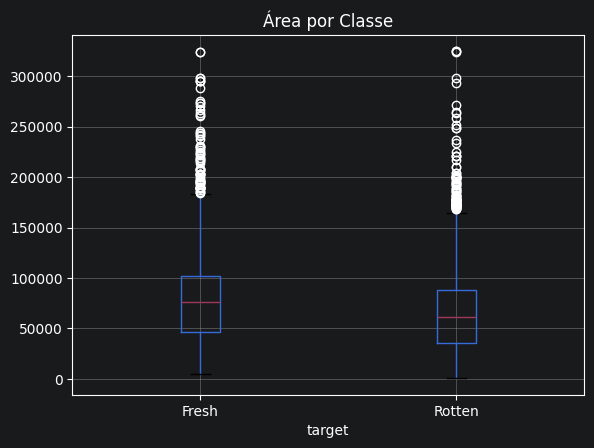

In [14]:
plt.figure(figsize=(8,5))

dados_plot = X_train_df.copy()

dados_plot["target"] = y_train_df

dados_plot.boxplot(column="area", by="target")

plt.title("Área por Classe")

plt.suptitle("")

plt.show()

<Figure size 800x500 with 0 Axes>

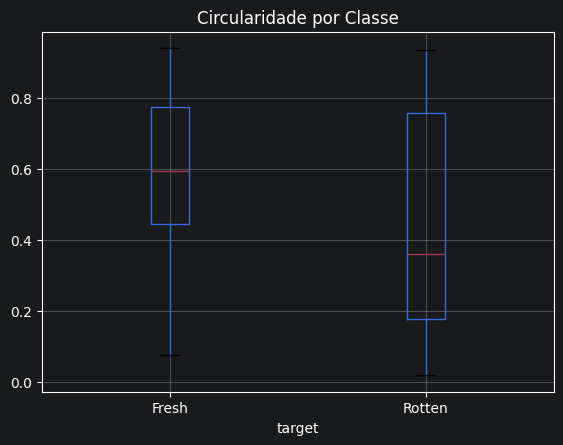

In [15]:
plt.figure(figsize=(8,5))

dados_plot.boxplot(column="circularity", by="target")

plt.title("Circularidade por Classe")

plt.suptitle("")

plt.show()

<Figure size 800x500 with 0 Axes>

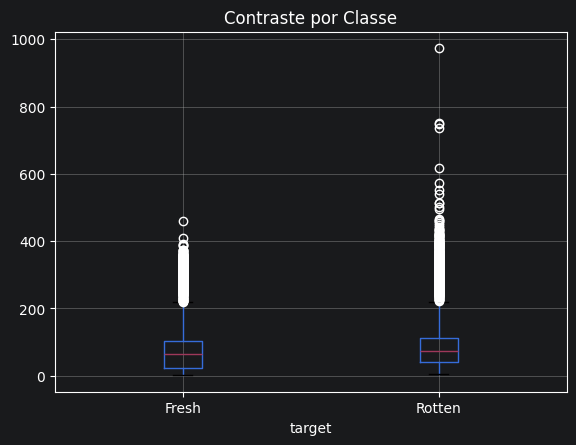

In [16]:
plt.figure(figsize=(8,5))

dados_plot.boxplot(column="contrast", by="target")

plt.title("Contraste por Classe")

plt.suptitle("")

plt.show()

<Figure size 800x500 with 0 Axes>

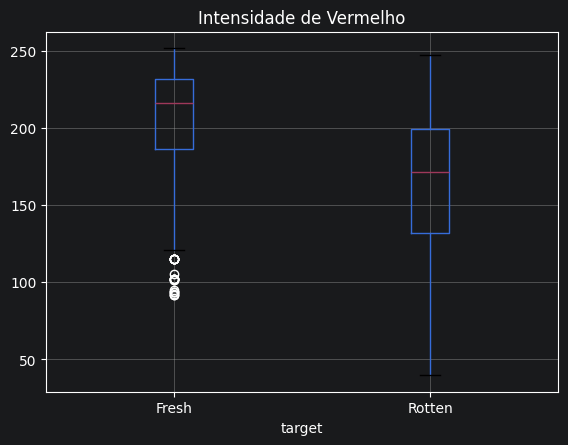

In [17]:
plt.figure(figsize=(8,5))

dados_plot = X_train_df.copy()

dados_plot["target"] = y_train_df

## intensidade red
dados_plot.boxplot(column="mean_r", by="target")

plt.title("Intensidade de Vermelho")

plt.suptitle("")

plt.show()

# 📈 | Histogramas

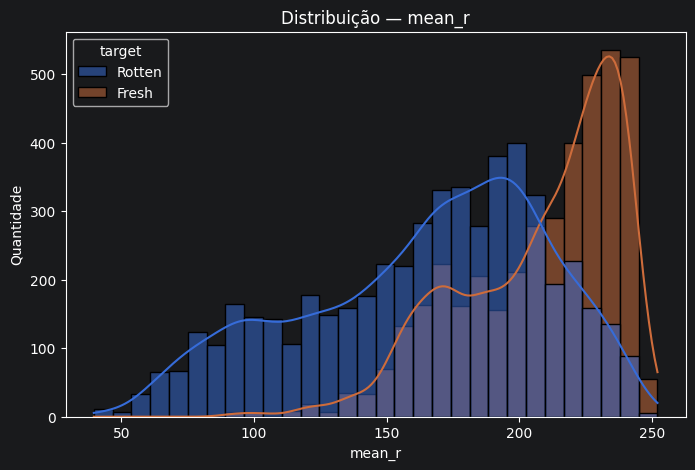

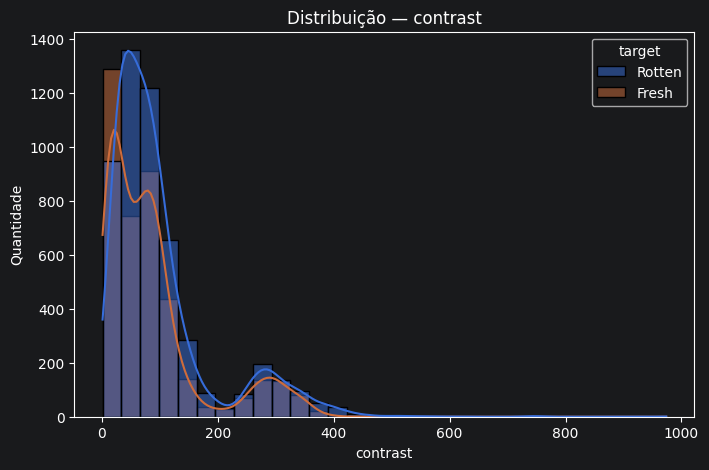

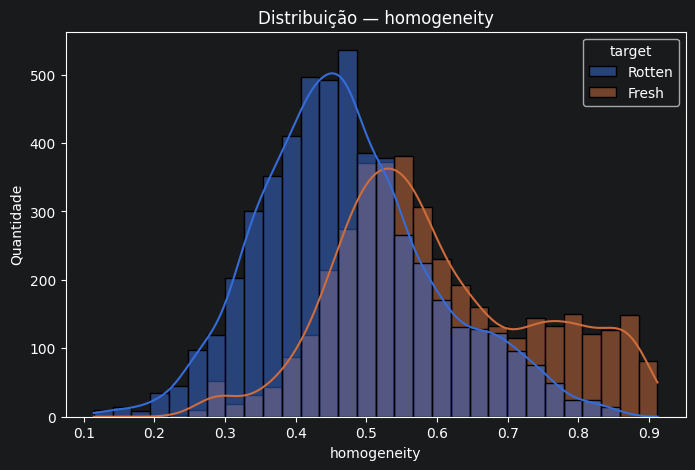

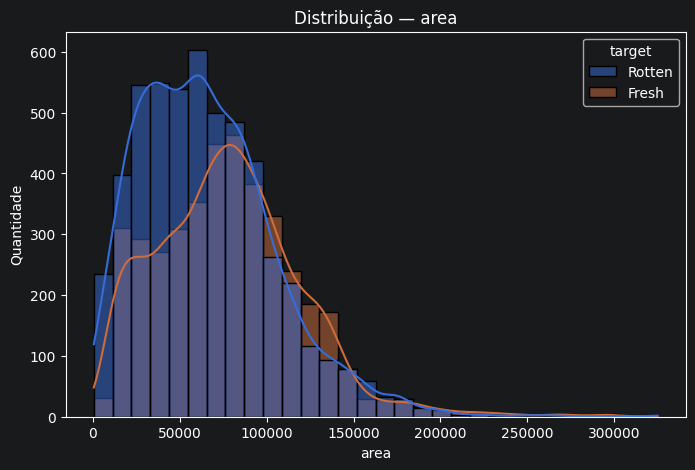

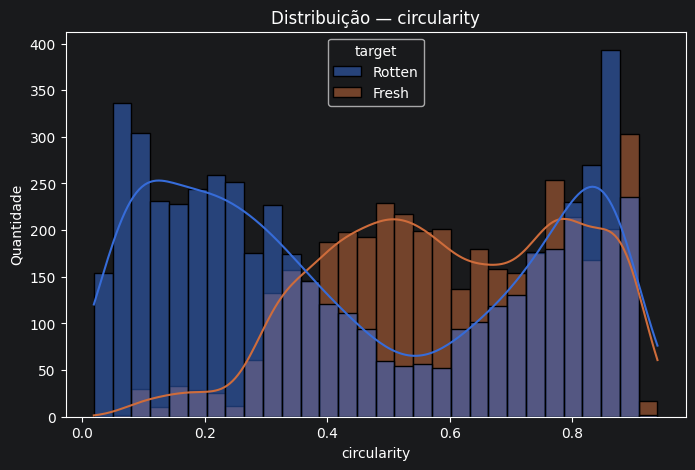

In [18]:
features_visualizar = [
    "mean_r",
    "contrast",
    "homogeneity",
    "area",
    "circularity"
]

for feature in features_visualizar:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=dados_plot,
        x=feature,
        hue="target",
        bins=30,
        kde=True
    )

    plt.title(f"Distribuição — {feature}")

    plt.xlabel(feature)

    plt.ylabel("Quantidade")

    plt.show()

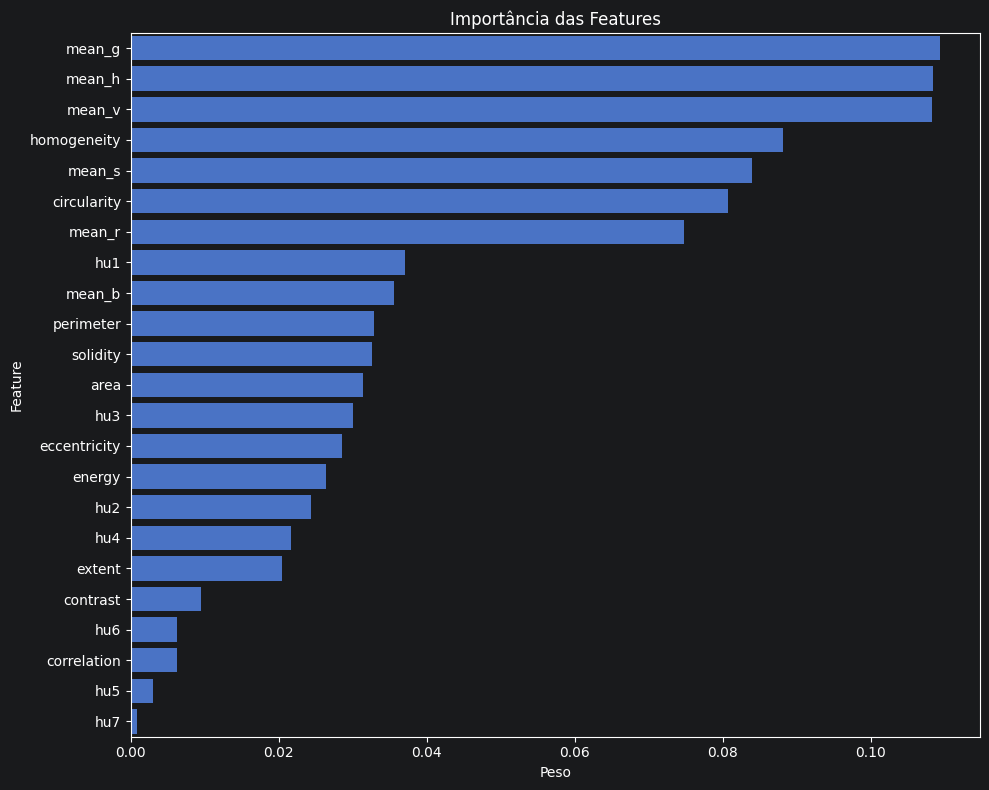

In [19]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(random_state=42,n_estimators=100)

rf.fit(X_train_df,y_train_df)

importancias = pd.DataFrame({"feature": X_train_df.columns,"importance": rf.feature_importances_})

importancias = importancias.sort_values(by="importance",ascending=False)

plt.figure(figsize=(10, 8))

sns.barplot(data=importancias,x="importance",y="feature")

plt.title("Importância das Features")
plt.xlabel("Peso")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


## Médias por Classe

In [20]:
medias = dados_plot.groupby("target").mean()

display(medias)

,area,perimeter,eccentricity,solidity,extent,circularity,hu1,hu2,hu3,hu4,...,mean_b,mean_g,mean_r,mean_h,mean_s,mean_v,contrast,homogeneity,energy,correlation
target,,,,,,,,,,,,,,,,,,,,,
Fresh,78117.658464,1309.431844,0.556237,0.894049,0.688218,0.598907,3.125371,7.781541,9.696447,9.834000,...,85.363117,156.183829,207.738428,30.163654,154.309316,211.833750,85.797757,0.598973,0.206426,0.982044
Rotten,65664.612550,1658.683349,0.587369,0.832329,0.631494,0.442156,3.054360,7.625614,9.681206,9.822939,...,80.213230,117.927080,164.278402,22.411128,128.479632,165.147903,100.239665,0.471729,0.161092,0.986312


## Total de frutas:

In [21]:
contagem = pd.Series(y_train_df).value_counts()

print(contagem)

Rotten    5211
Fresh     4023
Name: count, dtype: int64


#### Análise das Features

Os boxplots e as médias por classe indicam que algumas características apresentam diferenças entre frutas frescas e frutas deterioradas. As features relacionadas à textura, especialmente contraste e homogeneidade, mostraram maior potencial de separação entre as classes, o que é coerente com as alterações visuais causadas pelo processo de deterioração.

As características de cor também apresentaram diferenças entre as classes, enquanto algumas features de forma mostraram menor variação. Esses resultados sugerem que textura e cor são informações relevantes para a classificação do estado das frutas.

## Teste - Validação

In [22]:
print(X_train_df.duplicated().sum())

print(X_test_df.duplicated().sum())

0
0


In [23]:
print(
    pd.merge(
        X_train_df,
        X_test_df,
        how="inner"
    ).shape
)

(0, 23)


In [24]:
print(
    len(
        pd.merge(
            X_train_df.assign(split="train"),
            X_test_df.assign(split="test"),
            on=colunas
        )
    )
)

0


In [25]:
duplicadas = pd.merge(
    X_train_df,
    X_test_df,
    how="inner"
)

print(
    "Features repetidas:",
    len(duplicadas)
)

display(
    duplicadas.head(10)
)

Features repetidas: 0


,area,perimeter,eccentricity,solidity,extent,circularity,hu1,hu2,hu3,hu4,...,mean_b,mean_g,mean_r,mean_h,mean_s,mean_v,contrast,homogeneity,energy,correlation


In [26]:
duplicadas.drop_duplicates().shape

(0, 23)

In [27]:
print(
    "Train únicos:",
    len(X_train_df.drop_duplicates())
)

print(
    "Test únicos:",
    len(X_test_df.drop_duplicates())
)

Train únicos: 9234
Test únicos: 2688
